In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
import os
print(os.getcwd())

/data/cmn_vamal/mwilson/gene-sgan


In [2]:

volumes = pd.read_csv("/data/cmn_vamal/mwilson/new_data/new_data_folder/nii_folder/firstseg_files/volumes.csv", index_col = 0)
print(volumes)

                                                    L_Accu  R_Caud  R_Accu  \
image                                                                        
002_S_0295_ADNI_12M4TS_PATIENT_2_MP-RAGE_2__all...   549.0  4409.0   171.0   
002_S_0413_ADNI_12M4_TS_2_MP-RAGE_2a__all_none_...   370.0  4760.0   218.0   
005_S_0223_ADNI_14M4_TS_2_MP-RAGE_2a__all_none_...   306.0  5105.0   112.0   
052_S_1346_520650_2_MP-RAGE_2__all_none_firstse...   387.0  5442.0   234.0   
052_S_1346_520650_2_MP-RAGE_2a__all_none_firsts...   466.0  5602.0   179.0   
...                                                    ...     ...     ...   
052_S_1251_5621341_2_MP-RAGE_3__all_none_firsts...   825.0  5231.0   642.0   
052_S_1251_ADNI_1F_2_MP-RAGE_2__all_none_firsts...   608.0  5223.0   589.0   
052_S_1251_ADNI_1F_2_MP-RAGE_2a__all_none_first...   731.0  5042.0   524.0   
052_S_1251_ADNI_1F_2_MP-RAGE_3__all_none_firsts...   718.0  5177.0   609.0   
052_S_1251_ADNI_3T12M4_TS_2_MP-RAGE_2__all_none...   901.0  5448

In [3]:
os.chdir("/data/cmn_vamal/mwilson/new_data/new_data_folder/nii_folder/Imbalanced-Data-Clustering-using-Equilibrium-K-Means/python")

In [4]:
print(volumes.index[0:100])

Index(['002_S_0295_ADNI_12M4TS_PATIENT_2_MP-RAGE_2__all_none_firstseg.nii.gz',
       '002_S_0413_ADNI_12M4_TS_2_MP-RAGE_2a__all_none_firstseg.nii.gz',
       '005_S_0223_ADNI_14M4_TS_2_MP-RAGE_2a__all_none_firstseg.nii.gz',
       '052_S_1346_520650_2_MP-RAGE_2__all_none_firstseg.nii.gz',
       '052_S_1346_520650_2_MP-RAGE_2a__all_none_firstseg.nii.gz',
       '052_S_1346_520650_2_MP-RAGE_3__all_none_firstseg.nii.gz',
       '052_S_1346_520650_2_MP-RAGE_4__all_none_firstseg.nii.gz',
       '052_S_1346_ADNI_1F_2_MP-RAGE_2__all_none_firstseg.nii.gz',
       '052_S_1346_ADNI_1F_2_MP-RAGE_2a__all_none_firstseg.nii.gz',
       '052_S_1346_ADNI_1F_2_MP-RAGE_2b__all_none_firstseg.nii.gz',
       '052_S_1346_ADNI_1F_2_MP-RAGE_3__all_none_firstseg.nii.gz',
       '052_S_1352_1282069_2_MP-RAGE_3__all_none_firstseg.nii.gz',
       '052_S_1352_ADNI_1F_2_MP-RAGE_2__all_none_firstseg.nii.gz',
       '005_S_0324_ADNI_12M4_TS.dat_2_MP-RAGE_2__all_none_firstseg.nii.gz',
       '052_S_1352_ADNI_1F_2_M

In [35]:
#os.chdir("python")
os.getcwd()
X = np.random.randn(500, 4)
print(X)
print(volumes.columns)
print(volumes.iloc[0,:])
volumes_np = np.array(volumes)

[[-0.5361923   0.20137106 -0.7009346  -1.04518877]
 [ 0.06293388  2.18104258 -1.87032717  0.5920363 ]
 [-1.30050029  1.84683203  0.57557094 -1.10542722]
 ...
 [ 1.47817831 -1.45008633  0.30831502  1.37245323]
 [ 0.07019011  0.65413412  0.88068318 -0.77579465]
 [ 1.04058631  0.51123568 -0.56392693  1.97163191]]
Index(['L_Accu', 'R_Caud', 'R_Accu', 'R_Thal', 'L_Thal', 'R_Pall', 'L_Caud',
       'R_Hipp', 'R_Puta', 'L_Hipp', 'L_Puta', 'R_Amyg', 'L_Amyg', 'L_Pall'],
      dtype='object')
L_Accu     549.0
R_Caud    4409.0
R_Accu     171.0
R_Thal    9756.0
L_Thal    9728.0
R_Pall    2194.0
L_Caud    4268.0
R_Hipp    4508.0
R_Puta    6613.0
L_Hipp    4459.0
L_Puta    6374.0
R_Amyg     969.0
L_Amyg    1531.0
L_Pall    2328.0
Name: 002_S_0295_ADNI_12M4TS_PATIENT_2_MP-RAGE_2__all_none_firstseg.nii.gz, dtype: float64


In [6]:
vars(ekm)


NameError: name 'ekm' is not defined

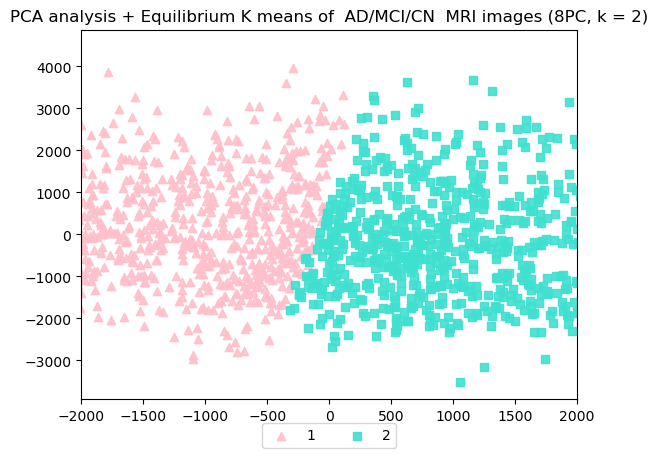

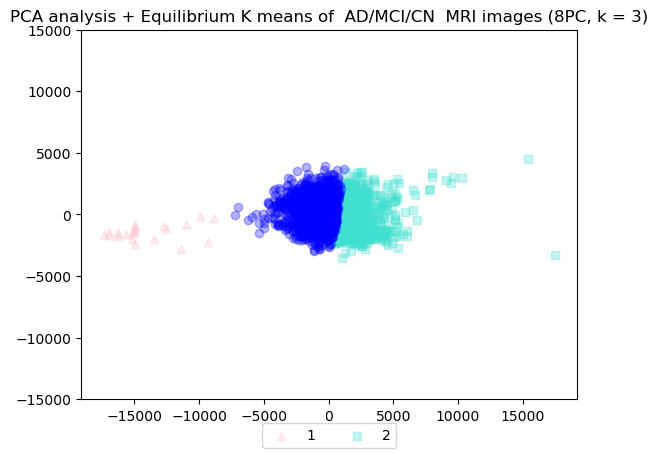

[Warning] Replicate 1: Failed to converge in 500 iterations.
[Warning] Replicate 1: Failed to converge in 500 iterations.


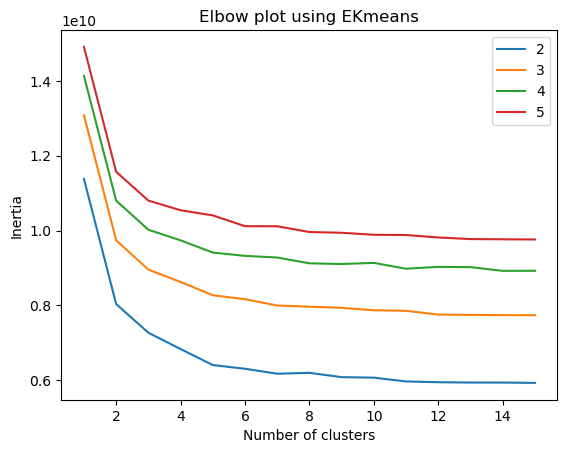

In [33]:
import ekm_sklearn
from ekm_sklearn import EKM
ekm = EKM(n_clusters=2, random_state=0, alpha='dvariance', scale=2.0, tol = 1e-3).fit(volumes_np)
y = (ekm.labels_)
pca_ekm2_labels = y
for i in range(1):
    fig, ax = plt.subplots()
    pca = PCA(n_components=8,random_state=42)
    pca_result = pca.fit_transform(volumes)
    for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
        ax.set_xlim(-2000, 2000) 
    plt.title(f"PCA analysis + Equilibrium K means of  AD/MCI/CN  MRI images (8PC, k = 2)")
    labels = [1,2]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol = 1e-3).fit(volumes_np)
y = (ekm.labels_)
pca_ekm_labels = y
for i in range(1):
    fig, ax = plt.subplots()
    pca = PCA(n_components=8,random_state=42)
    pca_result = pca.fit_transform(volumes)
    for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.3,
                    marker=m
                    )
        ax.set_ylim(-15000,15000)
    plt.title(f"PCA analysis + Equilibrium K means of  AD/MCI/CN  MRI images (8PC, k = 3)")
    labels = [1,2]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()

# Elbow plots 
k = np.arange(1,16,1)
for j in range(4):    
    x = []
    for i in range(15):
        pca = PCA(n_components=j+2,random_state=42)
        pca_result = pca.fit_transform(volumes)
        ekm = EKM(n_clusters=i+2, random_state=0, alpha='dvariance', scale=2.0, tol = 1e-3).fit(pca_result)
        a = (ekm.objective_)
        x.append(a)
    plt.plot(k, x, label = j+2)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.legend()
plt.title(f"Elbow plot using EKmeans")
plt.show()

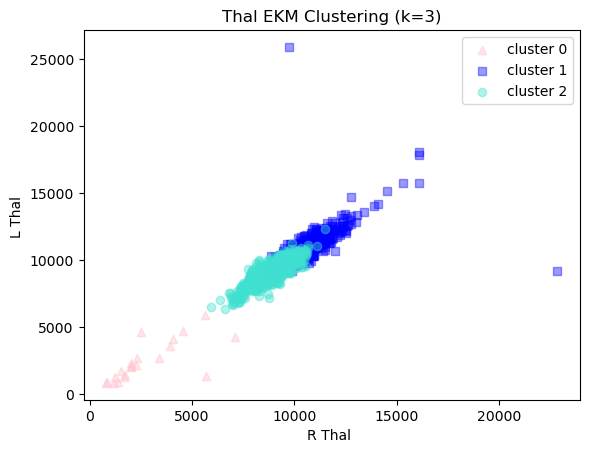

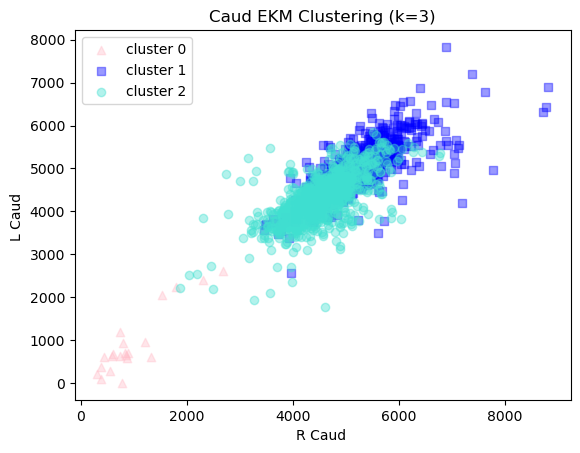

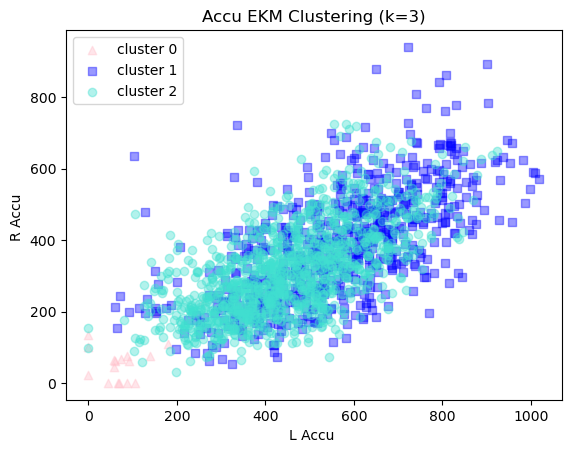

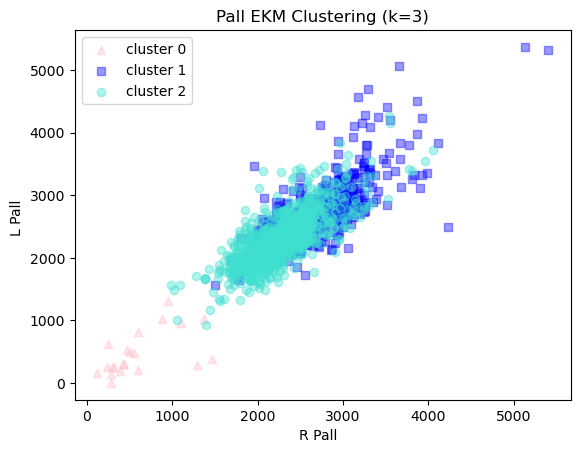

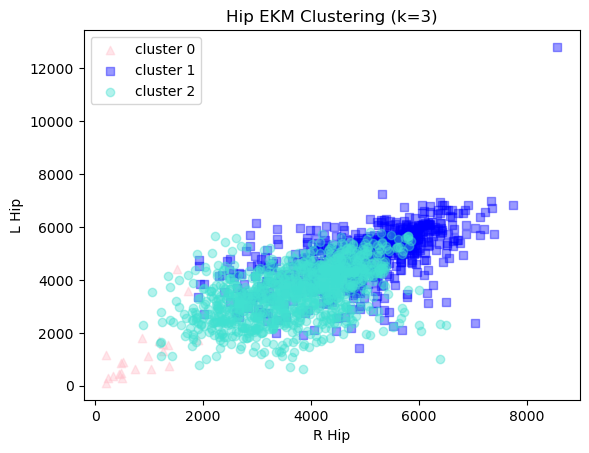

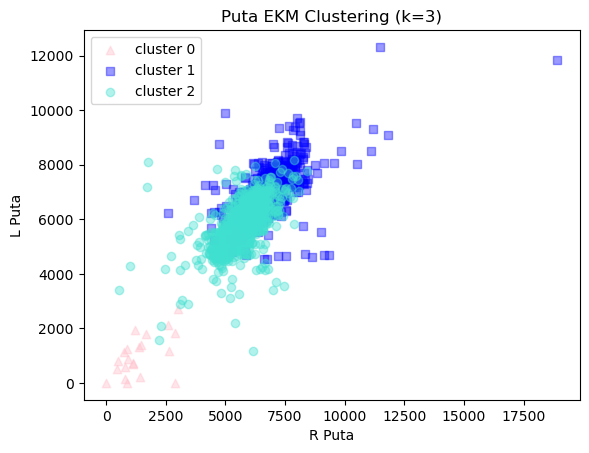

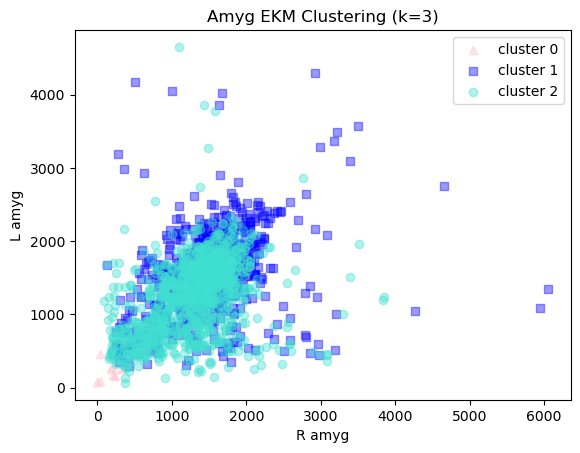

In [8]:
# only two biomarkers at a time
import ekm_sklearn
from ekm_sklearn import EKM

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(volumes_np)
y = ekm.labels_

x1 = volumes.iloc[:, 3]
x2 = volumes.iloc[:, 4]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Thal EKM Clustering (k=3)")
ax.set_xlabel("R Thal ")
ax.set_ylabel("L Thal ")
ax.legend()
plt.show()

# only two biomarkers at a time
import ekm_sklearn
from ekm_sklearn import EKM

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(volumes_np)
y = ekm.labels_

x1 = volumes.iloc[:, 1]
x2 = volumes.iloc[:, 6]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Caud EKM Clustering (k=3)")
ax.set_xlabel("R Caud ")
ax.set_ylabel("L Caud ")
ax.legend()
plt.show()

# only two biomarkers at a time
import ekm_sklearn
from ekm_sklearn import EKM

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(volumes_np)
y = ekm.labels_

x1 = volumes.iloc[:, 0]
x2 = volumes.iloc[:, 2]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Accu EKM Clustering (k=3)")
ax.set_xlabel("L Accu ")
ax.set_ylabel("R Accu ")
ax.legend()
plt.show()

x1 = volumes.iloc[:, 5]
x2 = volumes.iloc[:, 13]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Pall EKM Clustering (k=3)")
ax.set_xlabel("R Pall  ")
ax.set_ylabel("L Pall ")
ax.legend()
plt.show()

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(volumes_np)
y = ekm.labels_

x1 = volumes.iloc[:, 7]
x2 = volumes.iloc[:, 9]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Hip EKM Clustering (k=3)")
ax.set_xlabel("R Hip")
ax.set_ylabel("L Hip")
ax.legend()
plt.show()

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(volumes_np)
y = ekm.labels_

x1 = volumes.iloc[:, 8]
x2 = volumes.iloc[:, 10]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Puta EKM Clustering (k=3)")
ax.set_xlabel("R Puta")
ax.set_ylabel("L Puta")
ax.legend()
plt.show()

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(volumes_np)
y = ekm.labels_

x1 = volumes.iloc[:, 11]
x2 = volumes.iloc[:, 12]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Amyg EKM Clustering (k=3)")
ax.set_xlabel("R amyg")
ax.set_ylabel("L amyg")
ax.legend()
plt.show()

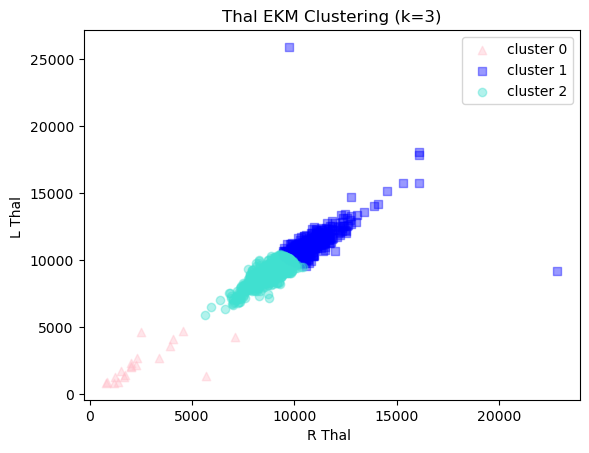

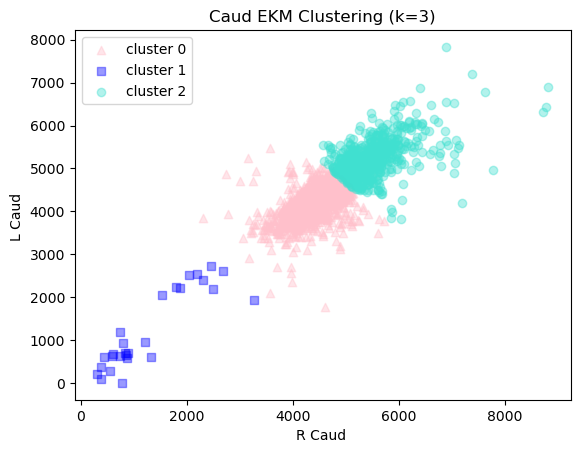

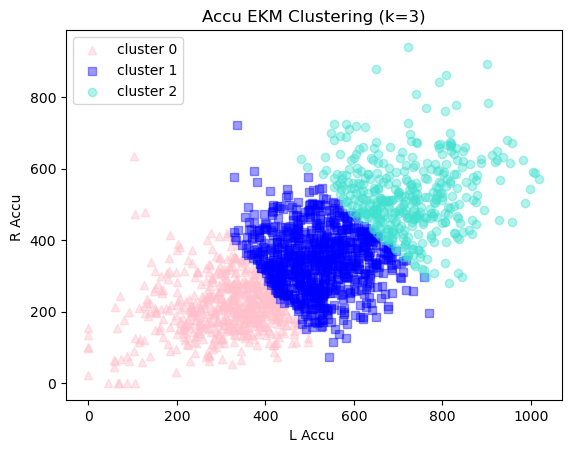

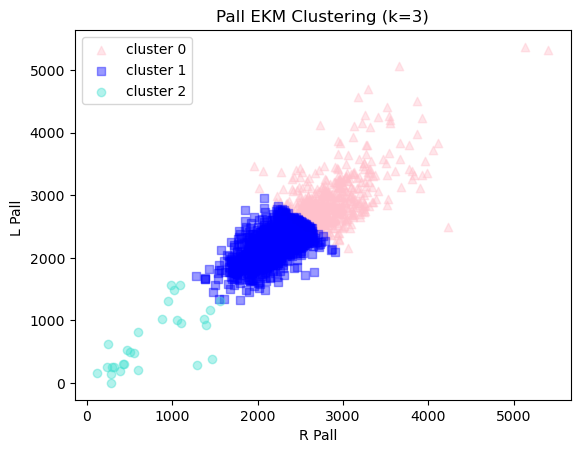

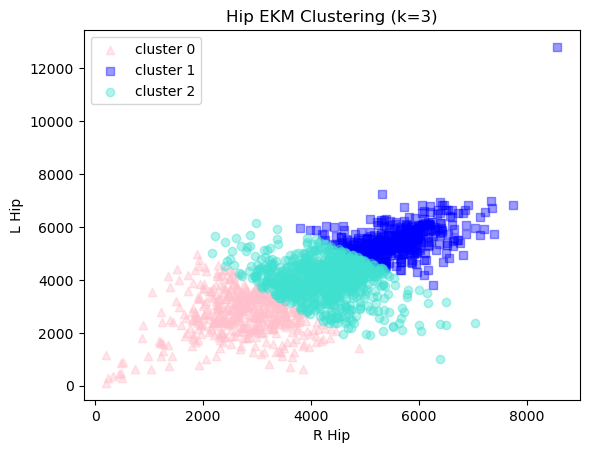

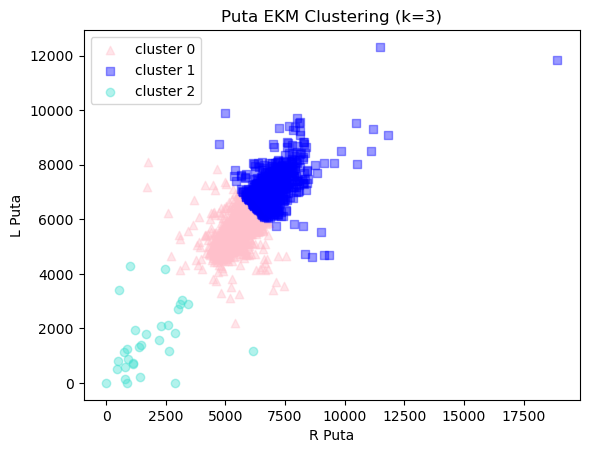

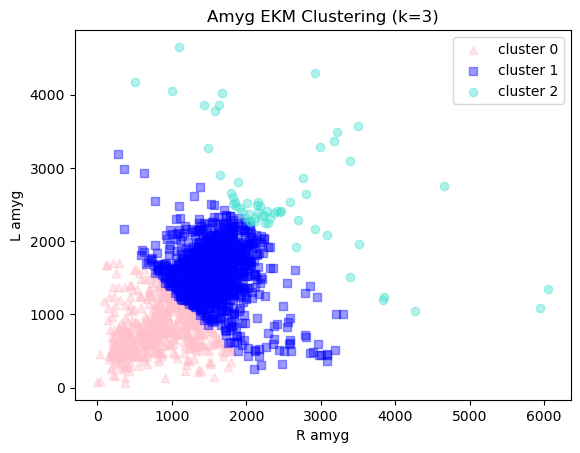

In [9]:
# only two biomarkers at a time
import ekm_sklearn
from ekm_sklearn import EKM
thal = np.array(volumes.iloc[:, [3,4]])

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(thal)
y = ekm.labels_

x1 = volumes.iloc[:, 3]
x2 = volumes.iloc[:, 4]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Thal EKM Clustering (k=3)")
ax.set_xlabel("R Thal ")
ax.set_ylabel("L Thal ")
ax.legend()
plt.show()

# only two biomarkers at a time
import ekm_sklearn
from ekm_sklearn import EKM

caud = np.array(volumes.iloc[:, [1,6]])

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(caud)
y = ekm.labels_

x1 = volumes.iloc[:, 1]
x2 = volumes.iloc[:, 6]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Caud EKM Clustering (k=3)")
ax.set_xlabel("R Caud ")
ax.set_ylabel("L Caud ")
ax.legend()
plt.show()

# only two biomarkers at a time
import ekm_sklearn
from ekm_sklearn import EKM
accu = np.array(volumes.iloc[:, [0,2]])

ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(accu)
y = ekm.labels_

x1 = volumes.iloc[:, 0]
x2 = volumes.iloc[:, 2]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Accu EKM Clustering (k=3)")
ax.set_xlabel("L Accu ")
ax.set_ylabel("R Accu ")
ax.legend()
plt.show()

pall = np.array(volumes.iloc[:, [5,13]])
ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(pall)
y = ekm.labels_
x1 = volumes.iloc[:, 5]
x2 = volumes.iloc[:, 13]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Pall EKM Clustering (k=3)")
ax.set_xlabel("R Pall  ")
ax.set_ylabel("L Pall ")
ax.legend()
plt.show()

hip = np.array(volumes.iloc[:, [7,9]])
ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(hip)
y = ekm.labels_

x1 = volumes.iloc[:, 7]
x2 = volumes.iloc[:, 9]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Hip EKM Clustering (k=3)")
ax.set_xlabel("R Hip")
ax.set_ylabel("L Hip")
ax.legend()
plt.show()

puta = np.array(volumes.iloc[:, [8,10]])
ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(puta)
y = ekm.labels_

x1 = volumes.iloc[:, 8]
x2 = volumes.iloc[:, 10]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Puta EKM Clustering (k=3)")
ax.set_xlabel("R Puta")
ax.set_ylabel("L Puta")
ax.legend()
plt.show()

amyg = np.array(volumes.iloc[:,[11,12]])
ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol=1e-3).fit(amyg)
y = ekm.labels_

x1 = volumes.iloc[:, 11]
x2 = volumes.iloc[:, 12]

fig, ax = plt.subplots()
for l, c, m in zip([0, 1,2], ["pink", "blue", "turquoise"], ['^', 's', "o"]):
    mask = y == l  # filter points belonging to cluster l
    ax.scatter(x1[mask],
               x2[mask],
               color=c,
               label='cluster %s' % l,
               alpha=0.4,
               marker=m)

plt.title("Amyg EKM Clustering (k=3)")
ax.set_xlabel("R amyg")
ax.set_ylabel("L amyg")
ax.legend()
plt.show()

In [10]:
# balancing the dataset manually 

print(metadata_reduced)

NameError: name 'metadata_reduced' is not defined

In [ ]:
print(volumes)

1821


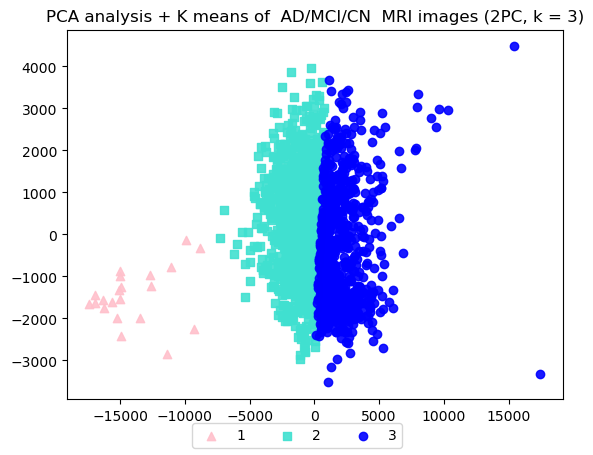

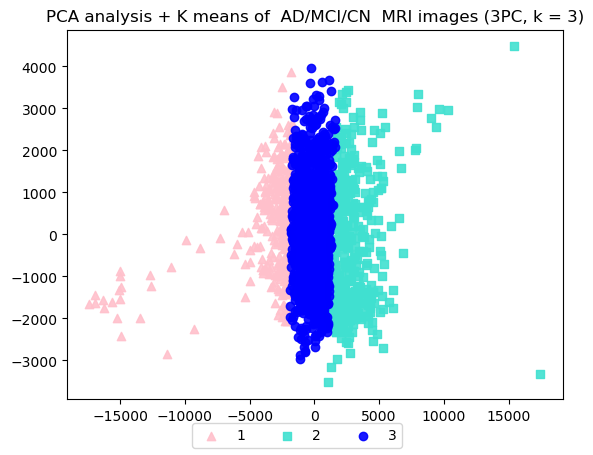

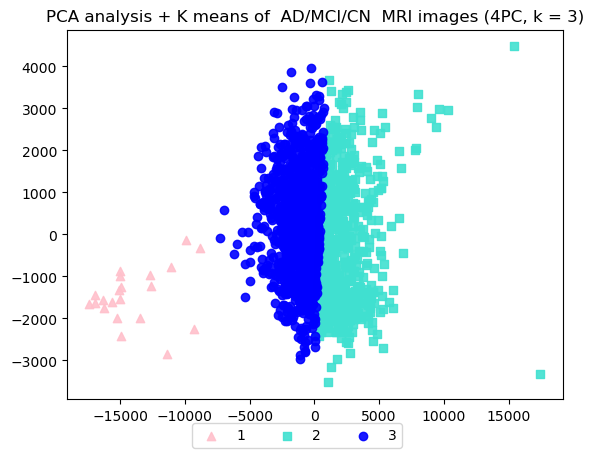

In [11]:
print(len(volumes))
for i in range(3):
    
    fig, ax = plt.subplots()
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(volumes)
    kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_
    for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"PCA analysis + K means of  AD/MCI/CN  MRI images ({i+2}PC, k = 3)")
    labels = [1,2,3]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()

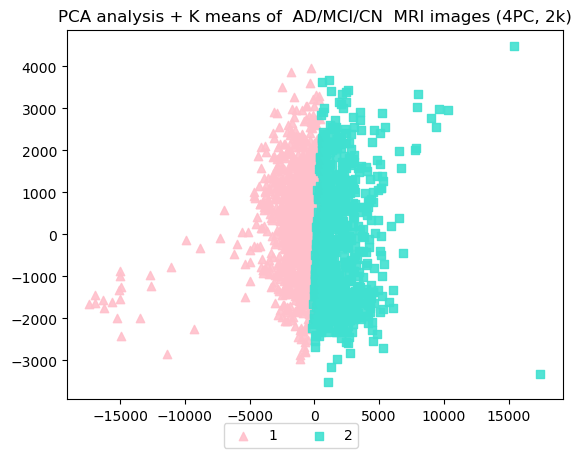

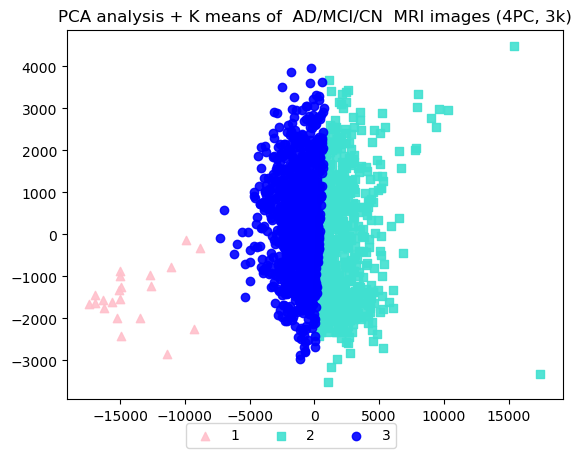

[1 2 1 ... 1 1 1]


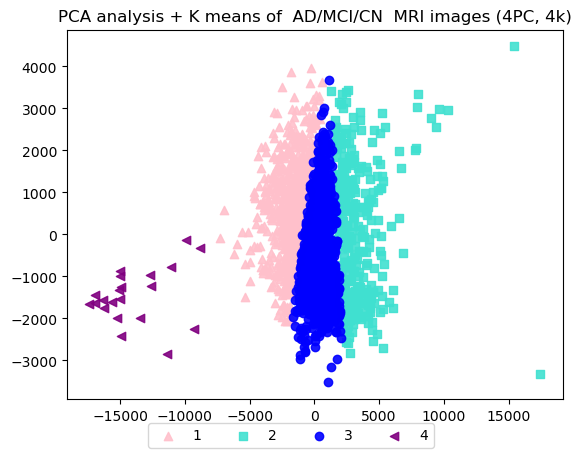

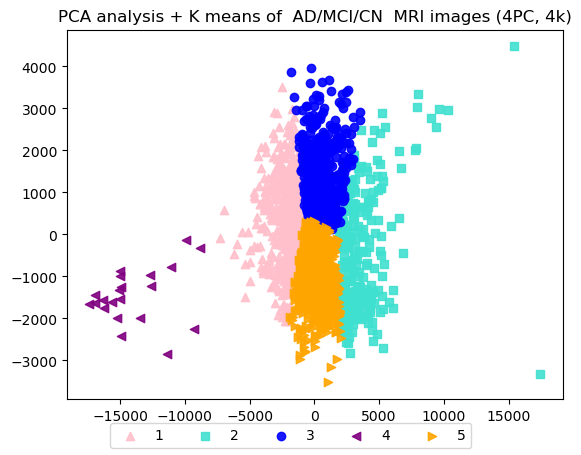

In [12]:
    fig, ax = plt.subplots()
    pca = PCA(n_components=4,random_state=42)
    pca_result = pca.fit_transform(volumes)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_
    for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"PCA analysis + K means of  AD/MCI/CN  MRI images (4PC, 2k)")
    labels = [1,2]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()

    fig, ax = plt.subplots()
    pca = PCA(n_components=4,random_state=42)
    pca_result = pca.fit_transform(volumes)
    kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_
    for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"PCA analysis + K means of  AD/MCI/CN  MRI images (4PC, 3k)")
    labels = [1,2,3]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()

print(y)
yarray = np.array(y)

    fig, ax = plt.subplots()
    pca = PCA(n_components=4,random_state=42)
    pca_result = pca.fit_transform(volumes)
    kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_
    for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"PCA analysis + K means of  AD/MCI/CN  MRI images (4PC, 4k)")
    labels = [1,2,3,4]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()


    fig, ax = plt.subplots()
    pca = PCA(n_components=4,random_state=42)
    pca_result = pca.fit_transform(volumes)
    kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_
    for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"PCA analysis + K means of  AD/MCI/CN  MRI images (4PC, 4k)")
    labels = [1,2,3,4,5]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()


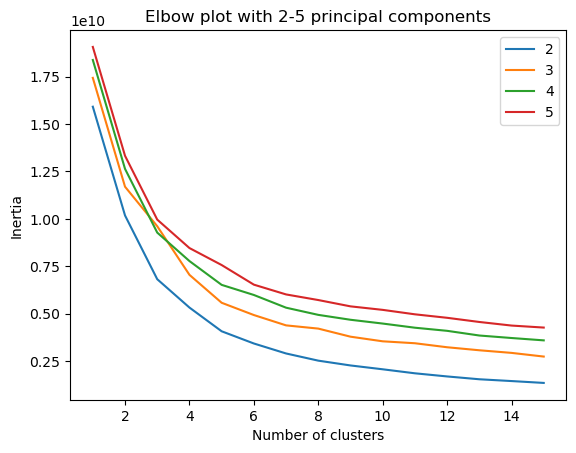

In [21]:
# Elbow plots 

k = np.arange(1,16,1)

for j in range(4):    
    x = []
    for i in range(15):
        pca = PCA(n_components=j+2,random_state=42)
        pca_result = pca.fit_transform(volumes)
        kmeans = KMeans(n_clusters=i+1, random_state=0, n_init="auto").fit(pca_result)
        a = (kmeans.inertia_)
        x.append(a)
    plt.plot(k, x, label = j+2)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.legend()
plt.title(f"Elbow plot with 2-5 principal components")
plt.show()

#for j in range(4):    
 #   x = []
  #  for i in range(15):
   #     pca = PCA(n_components=j+2,random_state=42)
    #    pca_result = pca.fit_transform(volumes)
     #   kmeans = KMeans(n_clusters=i+1, random_state=0, n_init="auto").fit(pca_result)
      #  a = (kmeans.inertia_)
       # x.append(a)
#    plt.plot(k, x)
 #   plt.xlabel("Number of clusters")
 #   plt.ylabel("Inertia")
 #   plt.title(f"Elbow plot using {j+2} principal components")
 #   plt.show()

In [22]:
import pandas as pd 
import os 

In [18]:

os.chdir("/data/cmn_vamal/mwilson/new_metadata/ADNI/")
os.getcwd()
metadata = pd.read_csv("combined_output.csv")
print(metadata)

     filename projectIdentifier  siteKey subjectIdentifier researchGroup  \
0      I10783              ADNI       27        027_S_0116           MCI   
1      I95031              ADNI       94        094_S_1293           MCI   
2      I34480              ADNI        5        005_S_0572           MCI   
3     I134136              ADNI       29        029_S_1318           MCI   
4      I80128              ADNI       29        029_S_0878           MCI   
...       ...               ...      ...               ...           ...   
1857   I40503              ADNI        2        002_S_1261            CN   
1858  I142699              ADNI      136        136_S_0186            CN   
1859  I119345              ADNI        5        005_S_1224           MCI   
1860   I11011              ADNI      128        128_S_0205           MCI   
1861   I15044              ADNI      137        137_S_0481           MCI   

     subjectSex  APOE_A1  APOE_A2    visitIdentifier  MMSCORE  ...  Matrix_Y  \
0      

In [19]:
metadata_reduced = metadata.iloc[:, [0,4]]
print(metadata_reduced)

     filename researchGroup
0      I10783           MCI
1      I95031           MCI
2      I34480           MCI
3     I134136           MCI
4      I80128           MCI
...       ...           ...
1857   I40503            CN
1858  I142699            CN
1859  I119345           MCI
1860   I11011           MCI
1861   I15044           MCI

[1862 rows x 2 columns]


In [20]:
import os 
import pandas as pd 
os.getcwd()

'/data/cmn_vamal/mwilson/new_metadata/ADNI'

In [22]:
final_metadata = pd.read_csv("/data/cmn_vamal/mwilson/new_metadata/final_metadata.csv")
final_metadata = final_metadata.iloc[:,[1,2,3]]
final_metadata["PCA/EKM K = 3"] = pca_ekm_labels
final_metadata["PCA/EKM K = 2"] = pca_ekm2_labels

In [31]:
print(final_metadata.iloc[0:50,[0,1,4]])
a = final_metadata.iloc[:,[1]]
for i in range(1821):
    if a.iloc[i,0] == "CN":
        a.iloc[i,0] = 0
    elif a.iloc[i,0] == "MCI":
        a.iloc[i,0] = 1
    else: 
        a.iloc[i,0] = 2

a.iloc[:,0] = a.iloc[:,0].astype(int)
accuracy_score(a, pca_ekm_labels)

m1 = []
m0 = []
a0 = []
a1 = []
c0 = []
c1 = []
for i in range(len(final_metadata)):
    researchgroup = final_metadata.iloc[i, 1]
    cluster = final_metadata.iloc[i, 4]
    if researchgroup == "MCI":
        if cluster == 0:
            m0.append(1)
        else:
            m1.append(1)
    elif researchgroup == "CN":
        if cluster == 0:
            c0.append(1)
        else:
            c1.append(1)
    else:
        if cluster == 0:
            a0.append(1)
        else:
            a1.append(1)
print(f"MCI, cluster 0: {sum(m0)}")
print(f"MCI, cluster 1: {sum(m1)}")
print(f"CN, cluster 0: {sum(c0)}")
print(f"CN, cluster 1: {sum(c1)}")
print(f"AD, cluster 0: {sum(a0)}")
print(f"AD, cluster 1: {sum(a1)}")

print(f"Cluster 0: {sum(m0)} MCI, {sum(c0)} CN, {sum(a0)} AD")
print(f"Cluster 1: {sum(m1)} MCI, {sum(c1)} CN, {sum(a1)} AD")

   image_id researchGroup  PCA/EKM K = 2
0    I10783           MCI              1
1    I95031           MCI              0
2    I34480           MCI              1
3   I134136           MCI              0
4    I80128           MCI              0
5    I91623            CN              0
6    I41122            CN              0
7   I164169           MCI              0
8   I105405            AD              0
9    I53944           MCI              0
10  I146853           MCI              0
11  I146581           MCI              1
12   I55827            AD              1
13  I133028            AD              0
14   I60900            AD              1
15  I168299            CN              1
16   I44518           MCI              1
17   I23468            CN              0
18   I30220            AD              0
19   I23213            CN              0
20   I29329           MCI              0
21   I27070           MCI              0
22   I42727            CN              0
23   I15848     

/tmp/ipykernel_737542/2728725157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 1
/tmp/ipykernel_737542/2728725157.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 0
/tmp/ipykernel_737542/2728725157.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 2
/tmp/ipykernel_737542/2728725157.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

MCI, cluster 0: 468
MCI, cluster 1: 516
CN, cluster 0: 249
CN, cluster 1: 279
AD, cluster 0: 161
AD, cluster 1: 148
Cluster 0: 468 MCI, 249 CN, 161 AD
Cluster 1: 516 MCI, 279 CN, 148 AD


In [53]:
# manually balancing the dataset 
print(metadata_reduced)
print(metadata_reduced.loc[metadata_reduced["researchGroup"] == "MCI", :])

cn = 535
ad = 322
mci = 1005




     filename researchGroup
0      I10783           MCI
1      I95031           MCI
2      I34480           MCI
3     I134136           MCI
4      I80128           MCI
...       ...           ...
1857   I40503            CN
1858  I142699            CN
1859  I119345           MCI
1860   I11011           MCI
1861   I15044           MCI

[1862 rows x 2 columns]
     filename researchGroup
0      I10783           MCI
1      I95031           MCI
2      I34480           MCI
3     I134136           MCI
4      I80128           MCI
...       ...           ...
1853  I145927           MCI
1855   I14240           MCI
1859  I119345           MCI
1860   I11011           MCI
1861   I15044           MCI

[1005 rows x 2 columns]
